# Walkthrough: Building Computer Vision Models

In this walkthrough, we'll put today's lecture concepts into practice:

1. **Load and explore** a color image dataset
2. **Preprocess** images: normalization and augmentation
3. **Build a CNN from scratch** and train it on image classification
4. **Apply transfer learning** and compare results

By the end, you'll see firsthand how preprocessing and transfer learning dramatically impact model performance!

---

## Part 1: Setup and Data Exploration

We'll use **CIFAR-10** - a classic dataset of 60,000 color images across 10 categories. It's the natural next step from MNIST: now we're working with **RGB color images** instead of grayscale!

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.16.1
GPU available: True


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(class_names)

print(f"Training images: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test images:     {X_test.shape}")
print(f"Test labels:     {y_test.shape}")
print(f"\nImage size: {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"Color channels: {X_train.shape[3]} (RGB!)")
print(f"Classes: {class_names}")
print(f"\nCompare to MNIST: 28x28x1 (grayscale) → CIFAR-10: 32x32x3 (color!)")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images:     (10000, 32, 32, 3)
Test labels:     (10000, 1)

Image size: 32x32 pixels
Color channels: 3 (RGB!)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Compare to MNIST: 28x28x1 (grayscale) → CIFAR-10: 32x32x3 (color!)


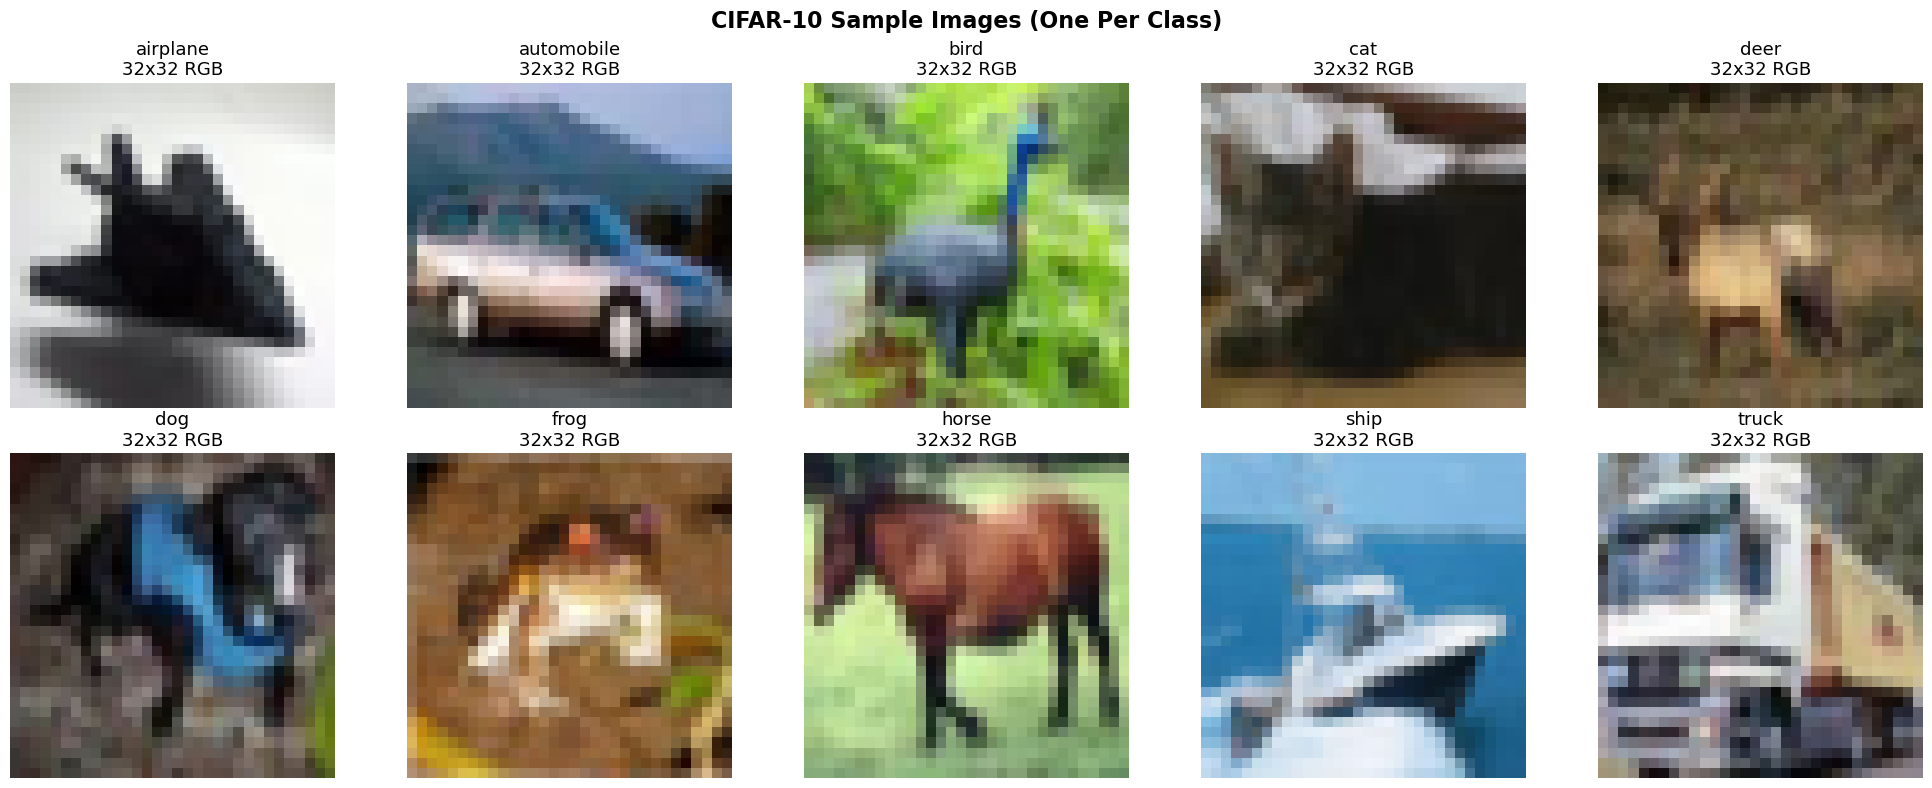

These images are small (32x32) but they're REAL color photos!
This is what makes computer vision challenging - can YOU tell what some of these are?


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('CIFAR-10 Sample Images (One Per Class)', fontsize=16, fontweight='bold')

for i, cls_name in enumerate(class_names):
    idx = np.where(y_train.flatten() == i)[0][0]
    ax = axes[i // 5][i % 5]
    ax.imshow(X_train[idx])
    ax.set_title(f"{cls_name}\n32x32 RGB", fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("These images are small (32x32) but they're REAL color photos!")
print("This is what makes computer vision challenging - can YOU tell what some of these are?")

In [4]:
sample_image = X_train[0]
print(f"Image shape: {sample_image.shape}")
print(f"Data type: {sample_image.dtype}")
print(f"Min pixel value: {sample_image.min()}")
print(f"Max pixel value: {sample_image.max()}")
print(f"\nPixel values range from 0 to 255 (raw RGB)")
print(f"\nFor our model, we need to NORMALIZE these to 0-1.")
print(f"Why? Smaller values help the model train faster and converge better.")

Image shape: (32, 32, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255

Pixel values range from 0 to 255 (raw RGB)

For our model, we need to NORMALIZE these to 0-1.
Why? Smaller values help the model train faster and converge better.


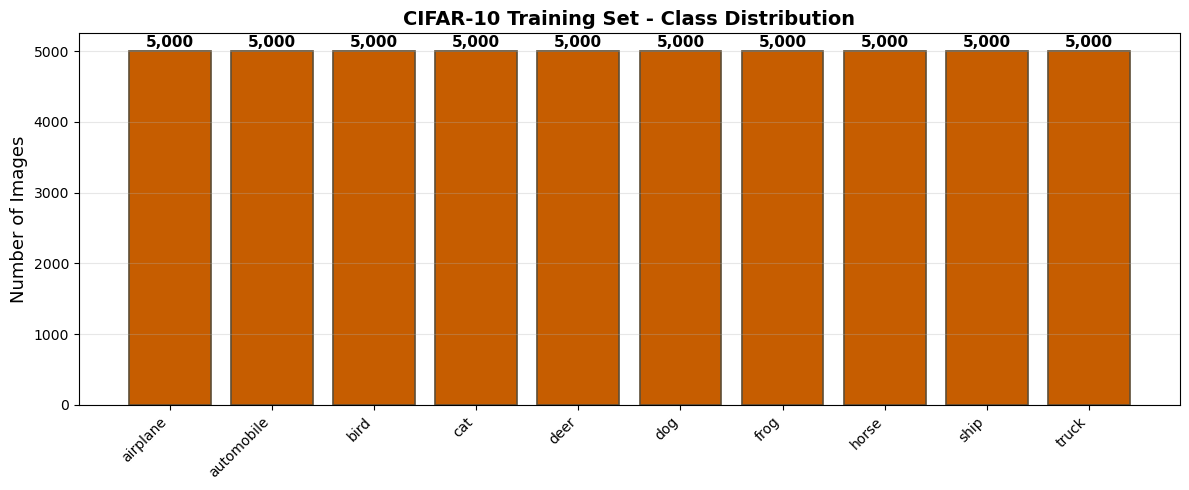

Each class has 5,000 training images - perfectly balanced!
Total: 50,000 training images, 10,000 test images


In [5]:
unique, counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, counts, color='#C65D00', edgecolor='#5D4E37', linewidth=1.2)
ax.set_ylabel('Number of Images', fontsize=13)
ax.set_title('CIFAR-10 Training Set - Class Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{count:,}', ha='center', fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Each class has {counts[0]:,} training images - perfectly balanced!")
print(f"Total: {len(y_train):,} training images, {len(y_test):,} test images")

### Key Observations

- **Color images (RGB)**: 3 channels instead of 1 - this is the real world!
- **Small resolution (32x32)**: Keeps training fast, but makes classification harder
- **Pixel values 0-255**: We need to normalize before training
- **Balanced classes**: 5,000 images per class - nice and even

---

## Part 2: Data Preprocessing

Now let's apply the preprocessing pipeline from our lecture:
1. **Normalize** pixel values from 0-255 to 0-1
2. **Create a validation split** from the training data
3. **Build efficient data pipelines** using `tf.data`

In [6]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print(f"Before normalization: min={X_train.min()}, max={X_train.max()}")
print(f"After normalization:  min={X_train_norm.min():.1f}, max={X_train_norm.max():.1f}")
print(f"\nAll pixel values are now between 0 and 1!")

Before normalization: min=0, max=255
After normalization:  min=0.0, max=1.0

All pixel values are now between 0 and 1!


In [7]:
val_size = 5000

X_val = X_train_norm[:val_size]
y_val = y_train[:val_size]
X_train_final = X_train_norm[val_size:]
y_train_final = y_train[val_size:]

print(f"Training set:   {X_train_final.shape[0]:,} images")
print(f"Validation set: {X_val.shape[0]:,} images")
print(f"Test set:       {X_test_norm.shape[0]:,} images")

Training set:   45,000 images
Validation set: 5,000 images
Test set:       10,000 images


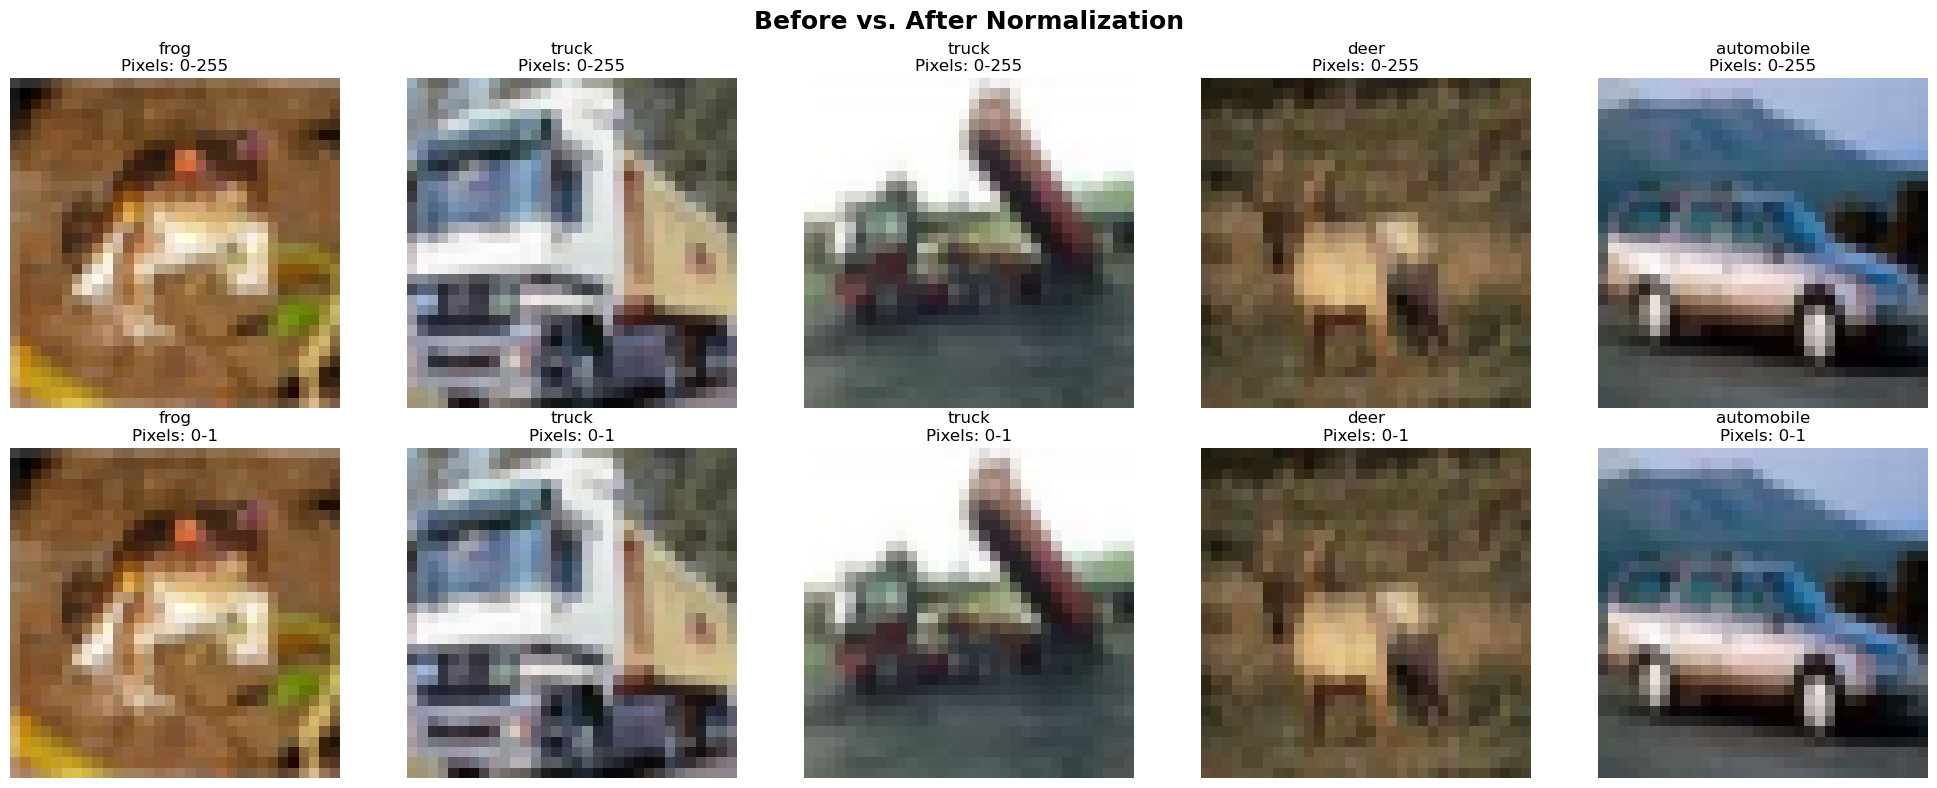

They look identical to us, but the number ranges are different.
The model trains MUCH better with values between 0 and 1!


In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Before vs. After Normalization', fontsize=18, fontweight='bold')

for i in range(5):
    axes[0][i].imshow(X_train[i])
    axes[0][i].set_title(f"{class_names[y_train[i][0]]}\nPixels: 0-255", fontsize=12)
    axes[0][i].axis('off')
    
    axes[1][i].imshow(X_train_norm[i])
    axes[1][i].set_title(f"{class_names[y_train[i][0]]}\nPixels: 0-1", fontsize=12)
    axes[1][i].axis('off')

axes[0][0].set_ylabel('RAW\n(0-255)', fontsize=14, fontweight='bold')
axes[1][0].set_ylabel('NORMALIZED\n(0-1)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("They look identical to us, but the number ranges are different.")
print("The model trains MUCH better with values between 0 and 1!")

In [9]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
train_dataset = (train_dataset
                 .shuffle(10000)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_norm, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Data pipelines ready!")
print(f"Batch size: {BATCH_SIZE}")
print(f"\nPipeline optimizations:")
print(f"  - shuffle(): Randomizes order each epoch")
print(f"  - batch(): Groups images into batches of {BATCH_SIZE}")
print(f"  - prefetch(): Prepares next batch while GPU is busy")

2026-02-19 22:28:30.183238: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-19 22:28:30.183265: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-02-19 22:28:30.183277: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-02-19 22:28:30.183548: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-19 22:28:30.183568: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Data pipelines ready!
Batch size: 32

Pipeline optimizations:
  - shuffle(): Randomizes order each epoch
  - batch(): Groups images into batches of 32
  - prefetch(): Prepares next batch while GPU is busy


---

## Part 3: Data Augmentation

Remember from the lecture: **data augmentation creates new training examples** by applying random transformations to existing images. This helps prevent overfitting and improves generalization.

Think of it like taking the same photo from different angles - a flipped cat is still a cat!

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

print("Augmentation layers defined!")
print("Transformations: Horizontal Flip, Rotation, Zoom, Translation")
print("\nThese are applied RANDOMLY each time an image passes through.")
print("So the model sees a slightly different version every epoch!")

Augmentation layers defined!
Transformations: Horizontal Flip, Rotation, Zoom, Translation

These are applied RANDOMLY each time an image passes through.
So the model sees a slightly different version every epoch!


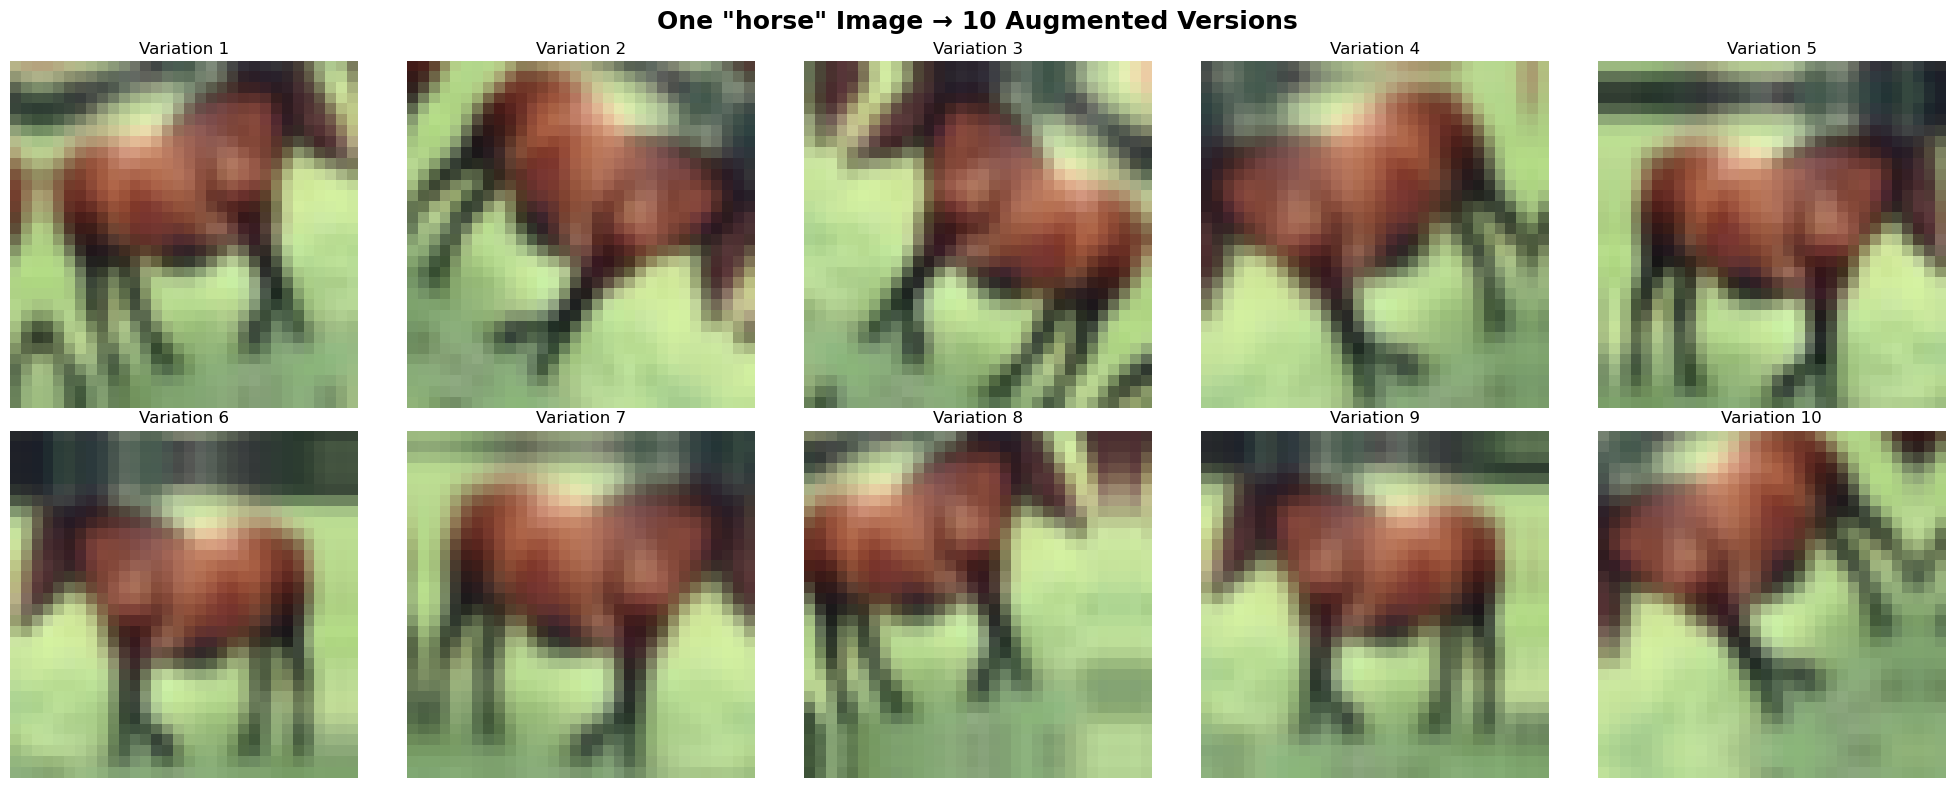

Same horse, 10 different augmented versions!
The model sees a different variation each epoch.
This forces it to learn REAL patterns, not memorize specific images.


In [11]:
sample_image = X_train_norm[7]
sample_label = y_train[7][0]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(f'One "{class_names[sample_label]}" Image → 10 Augmented Versions', 
             fontsize=18, fontweight='bold')

for i in range(10):
    ax = axes[i // 5][i % 5]
    augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    ax.imshow(augmented[0].numpy())
    ax.set_title(f"Variation {i+1}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Same {class_names[sample_label]}, 10 different augmented versions!")
print("The model sees a different variation each epoch.")
print("This forces it to learn REAL patterns, not memorize specific images.")

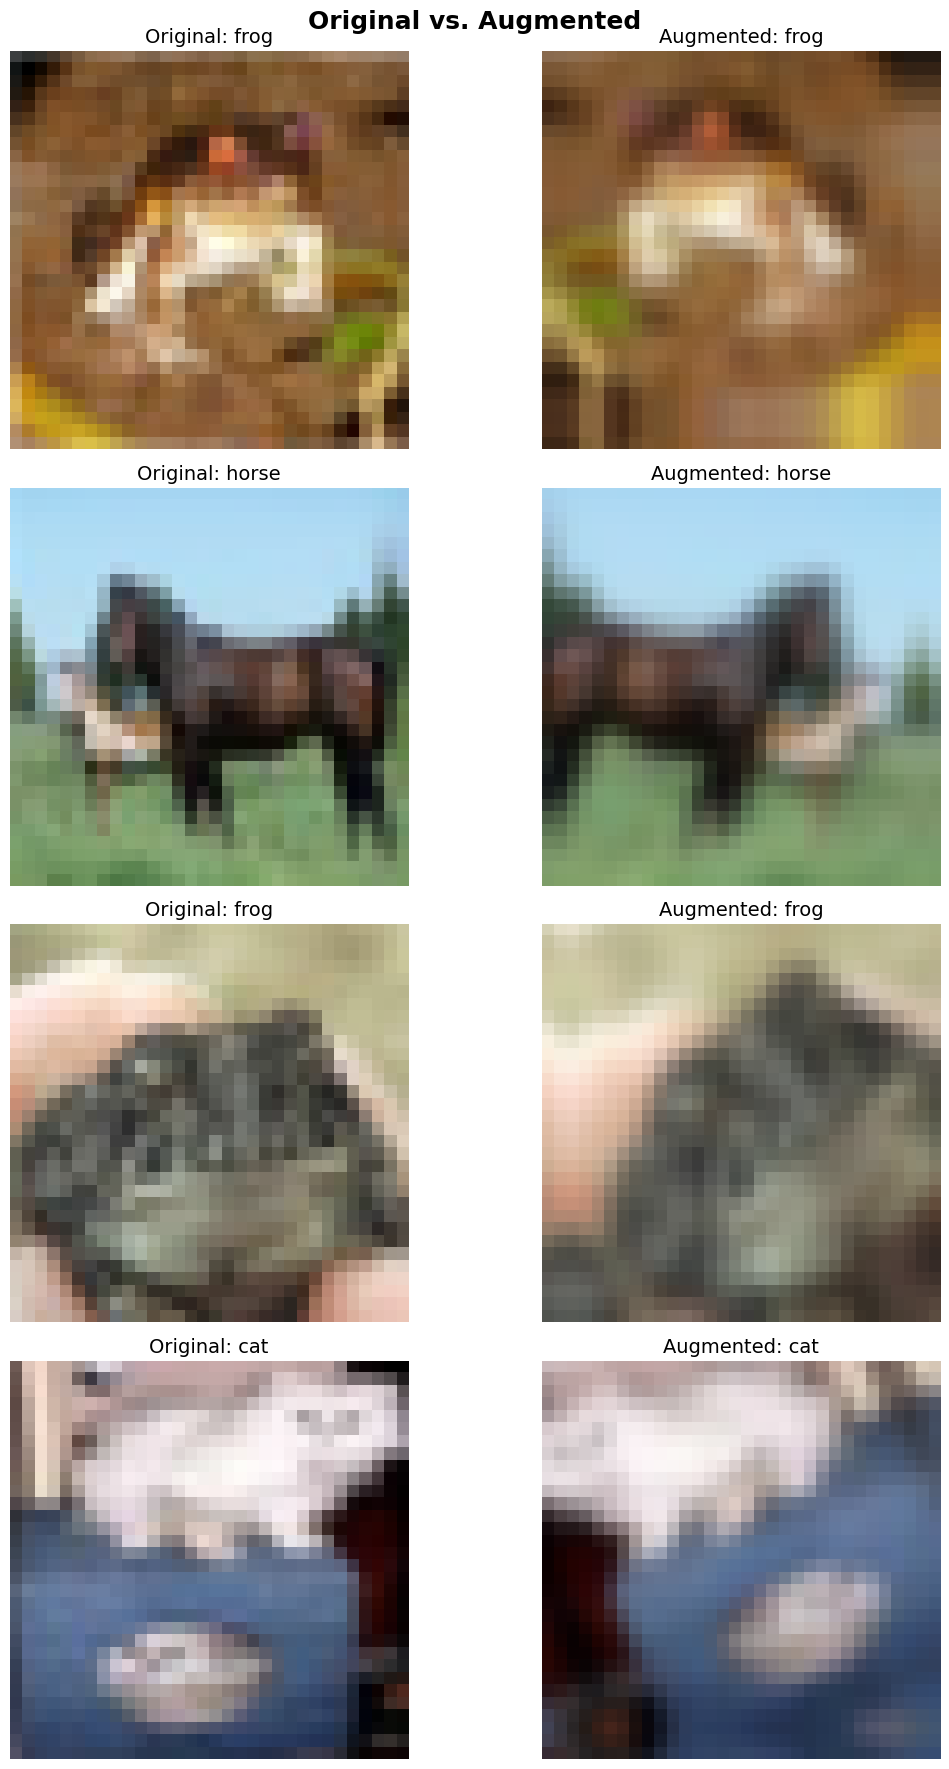

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))
fig.suptitle('Original vs. Augmented', fontsize=18, fontweight='bold')

sample_indices = [0, 12, 25, 38]
for i, idx in enumerate(sample_indices):
    img = X_train_norm[idx]
    label = y_train[idx][0]
    
    axes[i][0].imshow(img)
    axes[i][0].set_title(f"Original: {class_names[label]}", fontsize=14)
    axes[i][0].axis('off')
    
    augmented = data_augmentation(tf.expand_dims(img, 0), training=True)
    axes[i][1].imshow(augmented[0].numpy())
    axes[i][1].set_title(f"Augmented: {class_names[label]}", fontsize=14)
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

### Preprocessing Complete!

We've now applied the full preprocessing pipeline from our lecture:
- **Normalized** pixel values to 0-1
- **Created train/validation/test splits**
- **Built augmentation layers** for training diversity
- **Set up efficient data pipelines** with batching and prefetching

Now let's build our models!

---

## Part 4: Build a CNN from Scratch

First, let's build a CNN entirely from scratch - just like we learned in the last class. This will be our **baseline** that we'll compare against transfer learning later.

Architecture:
- Data augmentation layers
- Conv2D → MaxPool (x3 blocks)
- Flatten → Dense → Output

In [13]:
scratch_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    
    data_augmentation,
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='scratch_cnn')

print("CNN from scratch built!")

CNN from scratch built!


In [14]:
scratch_model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
scratch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")
print(f"Optimizer: Adam")
print(f"Loss: Sparse Categorical Crossentropy")
print(f"Metric: Accuracy")

Model compiled!
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Metric: Accuracy


In [17]:
EPOCHS_SCRATCH = 15

print(f"Training CNN from scratch for {EPOCHS_SCRATCH} epochs...")
print(f"The model is learning to recognize objects starting from random weights.\n")

scratch_history = scratch_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_SCRATCH
)

Training CNN from scratch for 15 epochs...
The model is learning to recognize objects starting from random weights.

Epoch 1/15


2026-02-19 22:30:06.159408: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.3226 - loss: 1.8378 - val_accuracy: 0.4728 - val_loss: 1.4459
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.4263 - loss: 1.5953 - val_accuracy: 0.5156 - val_loss: 1.3503
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.4594 - loss: 1.5182 - val_accuracy: 0.5058 - val_loss: 1.3787
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.4722 - loss: 1.4782 - val_accuracy: 0.5542 - val_loss: 1.2226
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.4870 - loss: 1.4582 - val_accuracy: 0.5382 - val_loss: 1.3102
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.4952 - loss: 1.4471 - val_accuracy: 0.5616 - val_loss: 1.2832
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.5007 - loss: 1.4589 - val_accuracy: 0.5970 - val_loss: 1.1674
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.5072 - loss: 1.45

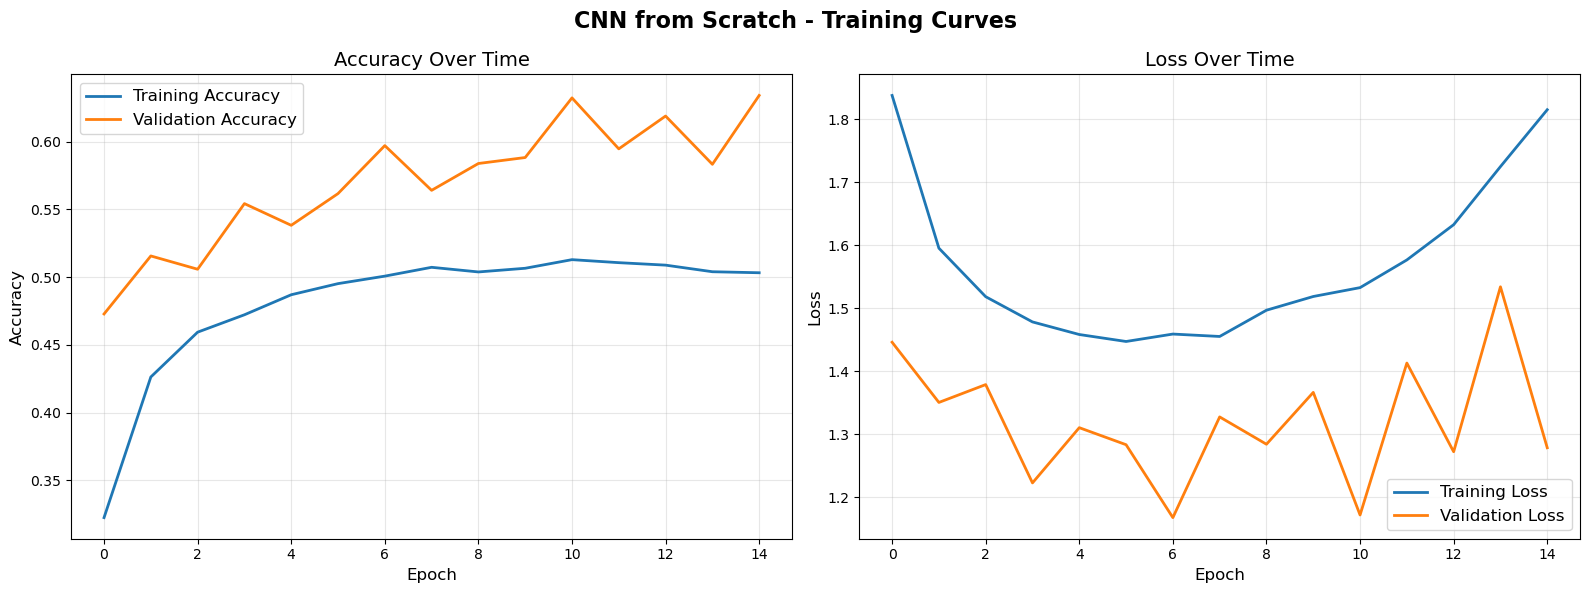


Final Training Accuracy: 0.5032
Final Validation Accuracy: 0.6340


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CNN from Scratch - Training Curves', fontsize=16, fontweight='bold')

ax1.plot(scratch_history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(scratch_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy Over Time', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(scratch_history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(scratch_history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Loss Over Time', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {scratch_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {scratch_history.history['val_accuracy'][-1]:.4f}")

In [19]:
scratch_test_loss, scratch_test_acc = scratch_model.evaluate(test_dataset)

print(f"\n{'='*50}")
print(f"CNN FROM SCRATCH - TEST RESULTS")
print(f"{'='*50}")
print(f"Test Accuracy: {scratch_test_acc:.4f} ({scratch_test_acc*100:.1f}%)")
print(f"Test Loss: {scratch_test_loss:.4f}")
print(f"{'='*50}")
print(f"\nRemember this number - we'll compare it to transfer learning next!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6331 - loss: 1.3038

CNN FROM SCRATCH - TEST RESULTS
Test Accuracy: 0.6331 (63.3%)
Test Loss: 1.3038

Remember this number - we'll compare it to transfer learning next!


### CNN from Scratch - Results

Not bad for a model that started from nothing! But our model had to learn EVERYTHING from random weights - what edges look like, what textures are, what shapes mean...

**Question to think about:** What if we could start with a model that already knows what edges, textures, and shapes look like?

That's exactly what transfer learning gives us!

---

## Part 5: Transfer Learning with MobileNetV2

Now let's use **transfer learning** with MobileNetV2 - a lightweight model pre-trained on **ImageNet** (14 million images, 1000+ categories).

MobileNetV2 already knows how to detect:
- Edges and corners (early layers)
- Textures and patterns (middle layers)
- Complex shapes and objects (deep layers)

We just need to teach it the difference between our 10 CIFAR-10 classes!

**Why MobileNetV2?** It's small, fast, and designed for efficiency - perfect for learning and for real-world deployment on phones and edge devices.

**Important:** MobileNetV2 expects larger images than 32x32, so we'll resize to 96x96. This is a great example of preprocessing in action!

In [20]:
TL_TRAIN_SIZE = 5000
TL_VAL_SIZE = 1000
TL_TEST_SIZE = 2000
IMG_SIZE = 96

print(f"For transfer learning, we'll use a subset to manage memory:")
print(f"  Training:   {TL_TRAIN_SIZE:,} images")
print(f"  Validation: {TL_VAL_SIZE:,} images")
print(f"  Test:       {TL_TEST_SIZE:,} images")
print(f"\nResizing from 32x32 → {IMG_SIZE}x{IMG_SIZE} for MobileNetV2")
print(f"\nThis is a real-world preprocessing step: models often need specific input sizes!")

For transfer learning, we'll use a subset to manage memory:
  Training:   5,000 images
  Validation: 1,000 images
  Test:       2,000 images

Resizing from 32x32 → 96x96 for MobileNetV2

This is a real-world preprocessing step: models often need specific input sizes!


In [21]:
def resize_images(images, size):
    """Resize a batch of images to the target size."""
    return tf.image.resize(images, (size, size)).numpy()

print("Resizing images for MobileNetV2 (this may take a moment)...")

X_train_resized = resize_images(X_train_norm[:TL_TRAIN_SIZE], IMG_SIZE)
y_train_resized = y_train[:TL_TRAIN_SIZE]

X_val_resized = resize_images(X_val[:TL_VAL_SIZE], IMG_SIZE)
y_val_resized = y_val[:TL_VAL_SIZE]

X_test_resized = resize_images(X_test_norm[:TL_TEST_SIZE], IMG_SIZE)
y_test_resized = y_test[:TL_TEST_SIZE]

print(f"\nResized training images: {X_train_resized.shape}")
print(f"Resized validation images: {X_val_resized.shape}")
print(f"Resized test images: {X_test_resized.shape}")
print(f"\n32x32 → {IMG_SIZE}x{IMG_SIZE} complete!")

Resizing images for MobileNetV2 (this may take a moment)...

Resized training images: (5000, 96, 96, 3)
Resized validation images: (1000, 96, 96, 3)
Resized test images: (2000, 96, 96, 3)

32x32 → 96x96 complete!


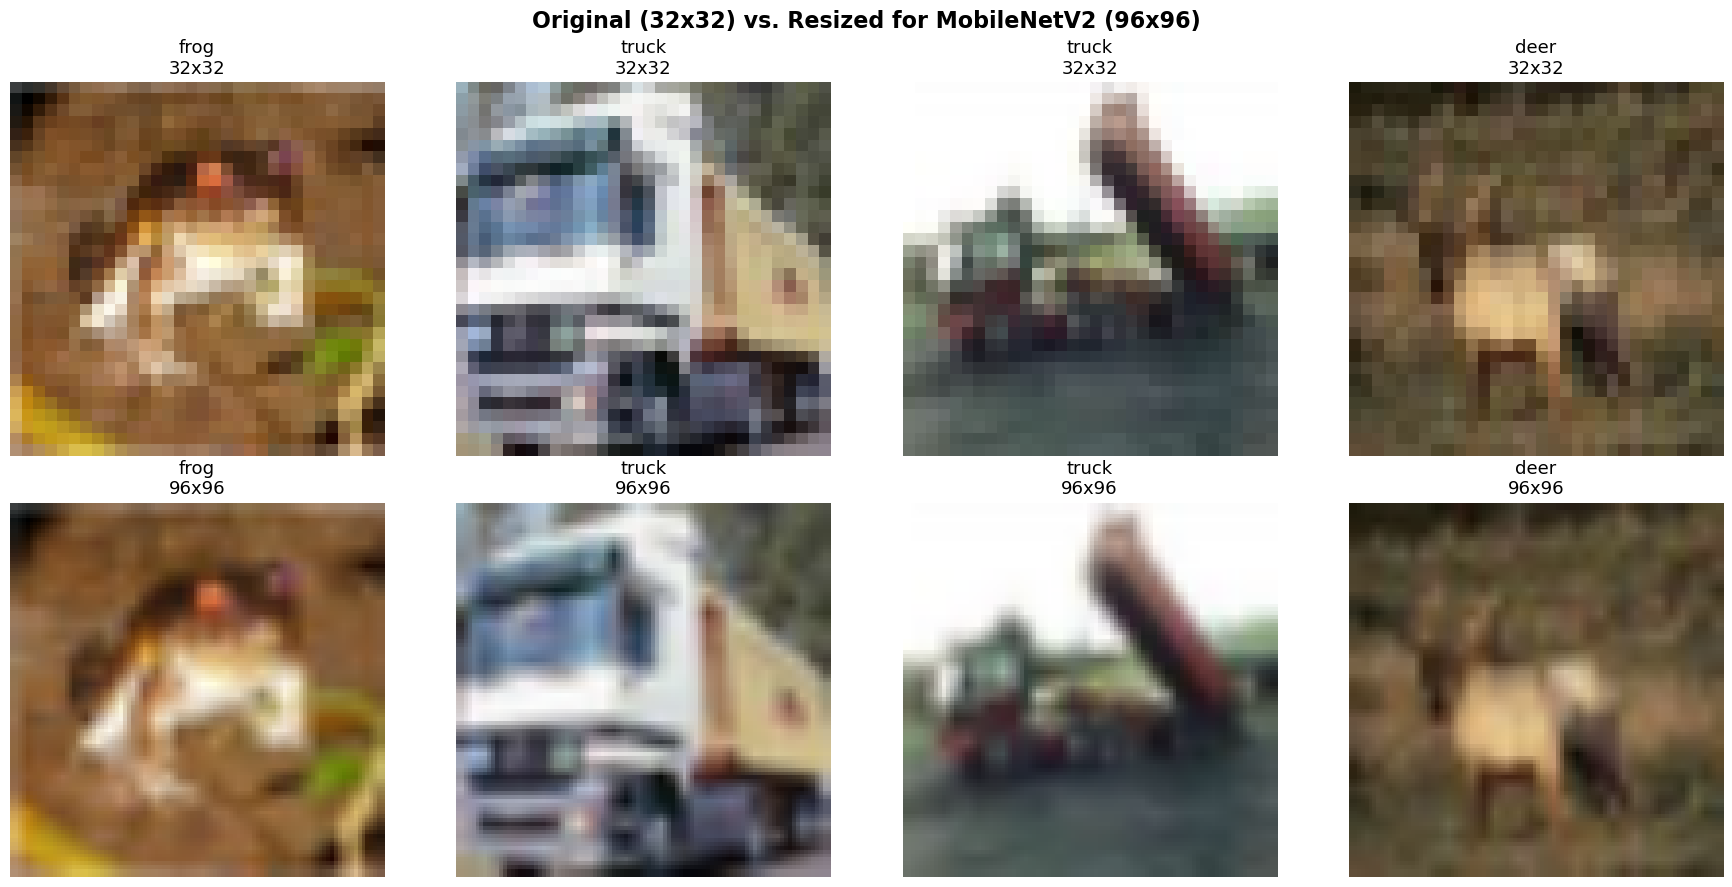

The resized images are slightly blurry because we're upscaling small images.
In the real world, you'd start with high-resolution images!
But the model can still learn from these - let's see how well.


In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Original (32x32) vs. Resized for MobileNetV2 (96x96)', fontsize=16, fontweight='bold')

for i in range(4):
    axes[0][i].imshow(X_train_norm[i])
    axes[0][i].set_title(f"{class_names[y_train[i][0]]}\n32x32", fontsize=13)
    axes[0][i].axis('off')
    
    axes[1][i].imshow(X_train_resized[i])
    axes[1][i].set_title(f"{class_names[y_train[i][0]]}\n96x96", fontsize=13)
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Original\n32x32', fontsize=14, fontweight='bold')
axes[1][0].set_ylabel('Resized\n96x96', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("The resized images are slightly blurry because we're upscaling small images.")
print("In the real world, you'd start with high-resolution images!")
print("But the model can still learn from these - let's see how well.")

In [23]:
train_tl = (tf.data.Dataset.from_tensor_slices((X_train_resized, y_train_resized))
            .shuffle(5000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_tl = (tf.data.Dataset.from_tensor_slices((X_val_resized, y_val_resized))
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

test_tl = (tf.data.Dataset.from_tensor_slices((X_test_resized, y_test_resized))
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

print("Transfer learning data pipelines ready!")

Transfer learning data pipelines ready!


In [24]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print(f"MobileNetV2 loaded with ImageNet weights!")
print(f"Total layers: {len(base_model.layers)}")
print(f"Total parameters: {base_model.count_params():,}")
print(f"\nThis model was trained on 14 MILLION images.")
print(f"It already knows what visual features look like!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded with ImageNet weights!
Total layers: 154
Total parameters: 2,257,984

This model was trained on 14 MILLION images.
It already knows what visual features look like!


In [25]:
base_model.trainable = False

print(f"Base model frozen!")
print(f"Non-trainable parameters: {base_model.count_params():,}")
print(f"\nThink of it like hiring an experienced employee:")
print(f"They already know the fundamentals - we just teach them OUR specific task.")

Base model frozen!
Non-trainable parameters: 2,257,984

Think of it like hiring an experienced employee:
They already know the fundamentals - we just teach them OUR specific task.


In [26]:
transfer_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='mobilenetv2_transfer')

print("Transfer learning model built!")

Transfer learning model built!


In [27]:
transfer_model.summary()

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
total_params = transfer_model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights)
frozen_params = total_params - trainable_params

print(f"{'='*50}")
print(f"PARAMETER BREAKDOWN")
print(f"{'='*50}")
print(f"Total parameters:     {total_params:>12,}")
print(f"Frozen (pre-trained): {frozen_params:>12,}  ({frozen_params/total_params*100:.1f}%)")
print(f"Trainable (our head): {trainable_params:>12,}  ({trainable_params/total_params*100:.1f}%)")
print(f"{'='*50}")
print(f"\nWe're only training {trainable_params/total_params*100:.1f}% of the parameters!")
print(f"The other {frozen_params/total_params*100:.1f}% already know how to see.")

PARAMETER BREAKDOWN
Total parameters:        2,588,490
Frozen (pre-trained):    2,257,984  (87.2%)
Trainable (our head):      330,506  (12.8%)

We're only training 12.8% of the parameters!
The other 87.2% already know how to see.


In [29]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer model compiled!")

Transfer model compiled!


In [30]:
EPOCHS_TRANSFER = 10

print(f"Training transfer learning model for {EPOCHS_TRANSFER} epochs...")
print(f"This should converge MUCH faster because MobileNetV2 already knows visual features!\n")

transfer_history = transfer_model.fit(
    train_tl,
    validation_data=val_tl,
    epochs=EPOCHS_TRANSFER
)

Training transfer learning model for 10 epochs...
This should converge MUCH faster because MobileNetV2 already knows visual features!

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.4594 - loss: 2.8825 - val_accuracy: 0.7260 - val_loss: 1.0056
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6122 - loss: 1.9626 - val_accuracy: 0.7570 - val_loss: 0.9301
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6580 - loss: 1.6230 - val_accuracy: 0.7840 - val_loss: 0.7194
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6938 - loss: 1.3176 - val_accuracy: 0.8050 - val_loss: 0.6925
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7220 - loss: 1.1860 - val_accuracy: 0.8300 - val_loss: 0.5248
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7454 - loss: 0.9797 - val_accuracy: 0.8410 - val_loss: 0.4688
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7544 - loss: 0.9017 - v

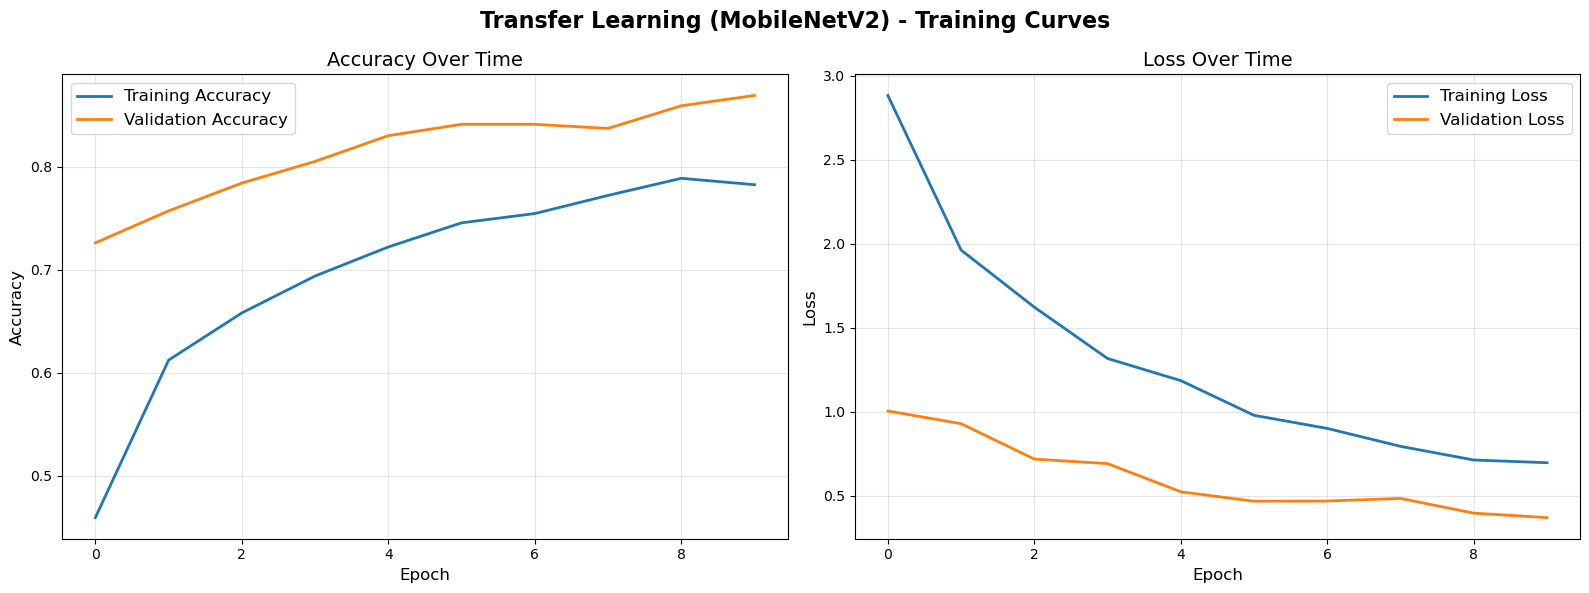


Final Training Accuracy: 0.7824
Final Validation Accuracy: 0.8690


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Transfer Learning (MobileNetV2) - Training Curves', fontsize=16, fontweight='bold')

ax1.plot(transfer_history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy Over Time', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(transfer_history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(transfer_history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Loss Over Time', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {transfer_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {transfer_history.history['val_accuracy'][-1]:.4f}")

In [32]:
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_tl)

print(f"\n{'='*50}")
print(f"TRANSFER LEARNING (MobileNetV2) - TEST RESULTS")
print(f"{'='*50}")
print(f"Test Accuracy: {transfer_test_acc:.4f} ({transfer_test_acc*100:.1f}%)")
print(f"Test Loss: {transfer_test_loss:.4f}")
print(f"{'='*50}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7630 - loss: 0.8204

TRANSFER LEARNING (MobileNetV2) - TEST RESULTS
Test Accuracy: 0.7630 (76.3%)
Test Loss: 0.8204


---

## Part 6: The Big Comparison

Now the moment of truth - let's compare our two approaches side by side!

**Note:** The scratch CNN trained on all 45,000 images, while the transfer learning model only used 5,000. Keep that in mind when comparing!

In [33]:
scratch_subset_loss, scratch_subset_acc = scratch_model.evaluate(
    X_test_norm[:TL_TEST_SIZE], y_test[:TL_TEST_SIZE], verbose=0
)

print(f"{'='*65}")
print(f"{'MODEL COMPARISON':^65}")
print(f"{'='*65}")
print(f"{'Metric':<30} {'CNN Scratch':<18} {'MobileNetV2 TL':<18}")
print(f"{'-'*65}")
print(f"{'Test Accuracy':<30} {scratch_subset_acc*100:<18.1f} {transfer_test_acc*100:<18.1f}")
print(f"{'Test Loss':<30} {scratch_subset_loss:<18.4f} {transfer_test_loss:<18.4f}")
print(f"{'Epochs Trained':<30} {EPOCHS_SCRATCH:<18} {EPOCHS_TRANSFER:<18}")
print(f"{'Training Images Used':<30} {'45,000':<18} {'5,000':<18}")
print(f"{'='*65}")

improvement = (transfer_test_acc - scratch_subset_acc) * 100
if improvement > 0:
    print(f"\nTransfer learning improvement: +{improvement:.1f} percentage points!")
    print(f"And it used 9x LESS training data!")
else:
    print(f"\nInteresting! The scratch CNN held its own with 9x more data.")
    print(f"Transfer learning still trained faster with far less data.")

                        MODEL COMPARISON                         
Metric                         CNN Scratch        MobileNetV2 TL    
-----------------------------------------------------------------
Test Accuracy                  63.2               76.3              
Test Loss                      1.3112             0.8204            
Epochs Trained                 15                 10                
Training Images Used           45,000             5,000             

Transfer learning improvement: +13.2 percentage points!
And it used 9x LESS training data!


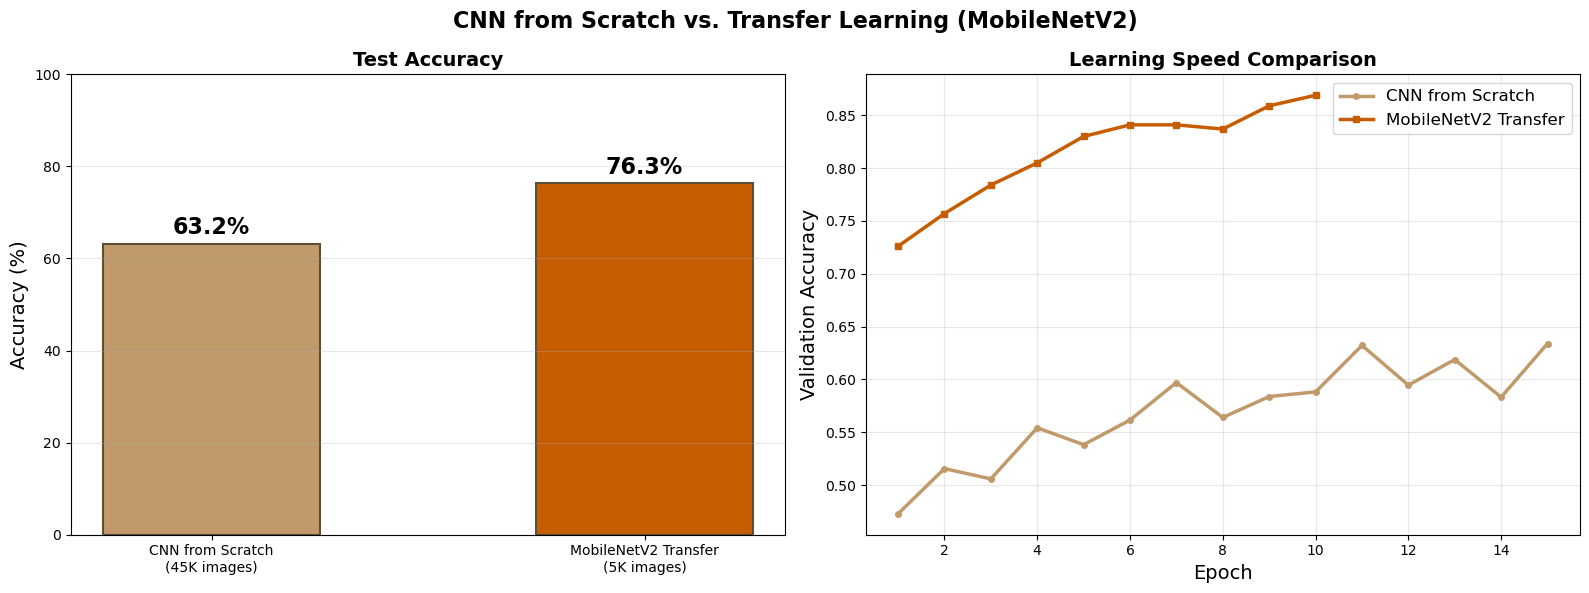

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CNN from Scratch vs. Transfer Learning (MobileNetV2)', fontsize=16, fontweight='bold')

model_names = ['CNN from Scratch\n(45K images)', 'MobileNetV2 Transfer\n(5K images)']
colors = ['#C19A6B', '#C65D00']

accuracies = [scratch_subset_acc * 100, transfer_test_acc * 100]
bars1 = ax1.bar(model_names, accuracies, color=colors, width=0.5, edgecolor='#5D4E37', linewidth=1.5)
ax1.set_ylabel('Accuracy (%)', fontsize=14)
ax1.set_title('Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

ax2.plot(range(1, EPOCHS_SCRATCH + 1), scratch_history.history['val_accuracy'], 
         label='CNN from Scratch', linewidth=2.5, color=colors[0], marker='o', markersize=4)
ax2.plot(range(1, EPOCHS_TRANSFER + 1), transfer_history.history['val_accuracy'], 
         label='MobileNetV2 Transfer', linewidth=2.5, color=colors[1], marker='s', markersize=4)
ax2.set_xlabel('Epoch', fontsize=14)
ax2.set_ylabel('Validation Accuracy', fontsize=14)
ax2.set_title('Learning Speed Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

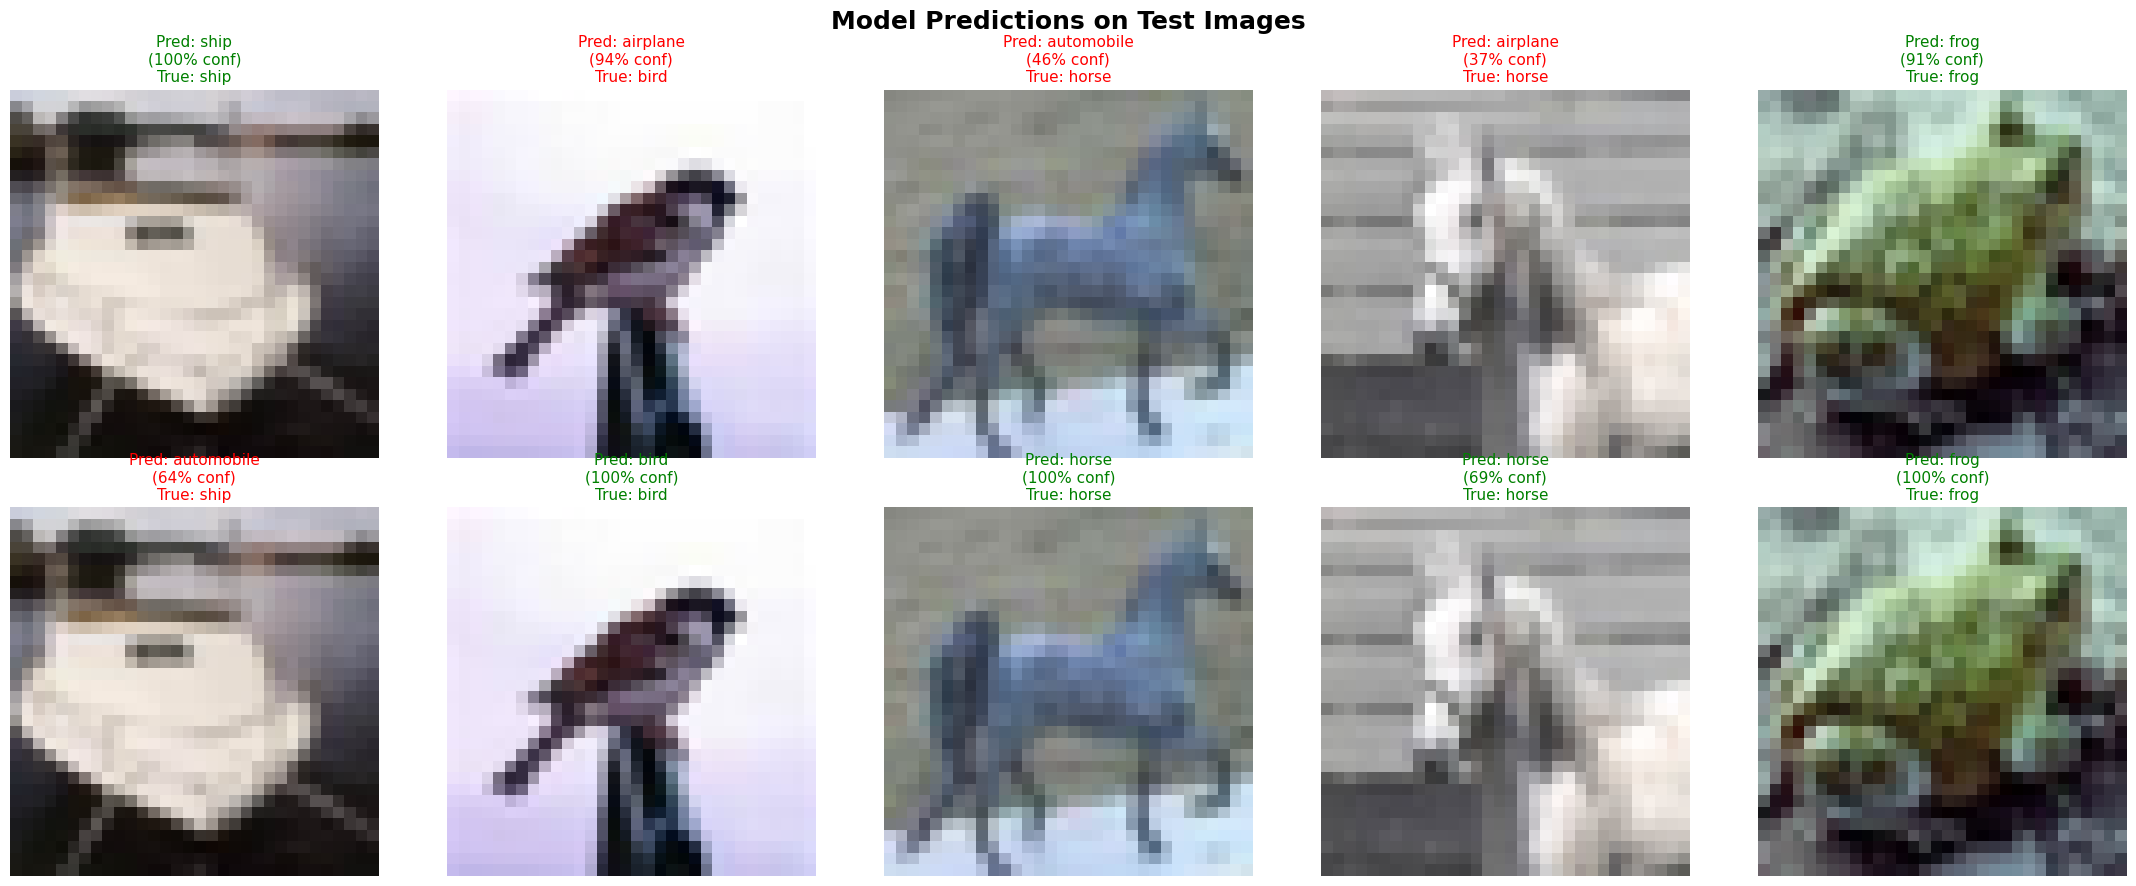

Green = correct prediction, Red = incorrect prediction


In [35]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Model Predictions on Test Images', fontsize=18, fontweight='bold')

sample_indices = np.random.choice(TL_TEST_SIZE, 5, replace=False)

for i, idx in enumerate(sample_indices):
    true_label = y_test[idx][0]
    
    scratch_pred = scratch_model.predict(X_test_norm[idx:idx+1], verbose=0)
    scratch_class = class_names[np.argmax(scratch_pred)]
    scratch_conf = np.max(scratch_pred) * 100
    correct_s = scratch_class == class_names[true_label]
    
    axes[0][i].imshow(X_test_norm[idx])
    axes[0][i].set_title(f"Pred: {scratch_class}\n({scratch_conf:.0f}% conf)\nTrue: {class_names[true_label]}", 
                         fontsize=11, color='green' if correct_s else 'red')
    axes[0][i].axis('off')
    
    transfer_pred = transfer_model.predict(X_test_resized[idx:idx+1], verbose=0)
    transfer_class = class_names[np.argmax(transfer_pred)]
    transfer_conf = np.max(transfer_pred) * 100
    correct_t = transfer_class == class_names[true_label]
    
    axes[1][i].imshow(X_test_norm[idx])
    axes[1][i].set_title(f"Pred: {transfer_class}\n({transfer_conf:.0f}% conf)\nTrue: {class_names[true_label]}", 
                         fontsize=11, color='green' if correct_t else 'red')
    axes[1][i].axis('off')

axes[0][0].set_ylabel('CNN from\nScratch', fontsize=14, fontweight='bold', rotation=0, labelpad=80)
axes[1][0].set_ylabel('MobileNetV2\nTransfer', fontsize=14, fontweight='bold', rotation=0, labelpad=80)

plt.tight_layout()
plt.show()

print("Green = correct prediction, Red = incorrect prediction")

---

## Part 7: Wrap-Up

### What We Accomplished Today

In this walkthrough, we put all of today's lecture concepts into practice:

1. **Loaded real-world color images** (CIFAR-10) and explored the RGB format
2. **Preprocessed images** with normalization (0-255 → 0-1) and data augmentation
3. **Visualized every step** to understand what preprocessing actually does
4. **Built a CNN from scratch** and trained it on image classification
5. **Resized images** from 32x32 to 96x96 for MobileNetV2 (real-world preprocessing!)
6. **Applied transfer learning** with MobileNetV2 (pre-trained on 14 million images)
7. **Compared results** and saw the impact of transfer learning

### Key Takeaways

- **Preprocessing is essential** - Normalization, resizing, and augmentation all matter
- **Data augmentation** helps prevent overfitting by creating training variations
- **Transfer learning** leverages pre-trained knowledge - you don't start from scratch
- **Pre-trained models** (like MobileNetV2) already understand visual features - you just teach them your task
- **Always try transfer learning first** - it's faster and usually better, especially with limited data!

Great work today! You just built and compared real computer vision models.